# EQPolarity-Torch: Texas 10% transfer learning

This is the **PyTorch replacement** for `run_eqpolarity_transferlearning_Texas_10percent.ipynb`.
It keeps the original workflow as closely as possible:

- start from the California/SCSN pretrained EQPolarity model;
- randomly select 10% of the Texas dataset;
- reserve 10% of that selected subset for validation (about 9% training + 1% validation of the complete Texas dataset);
- optimize with Adam at `1e-3`, batch size `128`, for up to `50` epochs;
- select the checkpoint with the highest validation accuracy;
- use a `0.5` decision threshold;
- retain the original confusion-matrix visualization style and figure names.

The original notebook imported `EarlyStopping` but did **not** attach it to `model.fit`, so this PyTorch notebook likewise does not introduce early stopping. The learning-rate scheduler mirrors the original `ReduceLROnPlateau(factor=0.1, patience=50, min_lr=0.5e-6, mode='max')` behavior.


In [1]:
# EQPolarity-Torch setup
from pathlib import Path
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

from eqpolarity_torch import load_model, predict_proba

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

# These defaults match the repository layout when this notebook is under notebooks/.
DATA_DIR = Path("../data/TexasData")
MODEL_DIR = Path("../models")
if not MODEL_DIR.exists():
    # load_model() can resolve weights from an editable eqpolarity-torch checkout.
    MODEL_DIR = None

from torch import nn
from torch.utils.data import DataLoader, TensorDataset


PyTorch: 2.10.0
Device : cpu


In [2]:
## Import data
# polall: Texas polarity labels (22980 x 1 in the original dataset)
# datall: 600-sample vertical-component waveforms centered on the analyst P arrival
#         (22980 x 600 x 1 in the original dataset)

polall = np.load(DATA_DIR / "polall_Texas.npy")

data = []
for ii in range(6):
    data.append(np.load(DATA_DIR / f"datall_Texas{ii+1}.npy"))
datall = np.concatenate(data, axis=0).astype(np.float32, copy=False)

# Keep sklearn labels one-dimensional while preserving the original 0=Up, 1=Down convention.
labtest = np.asarray(polall).reshape(-1).astype(np.int64)

print("datall:", datall.shape, datall.dtype)
print("polall:", polall.shape, polall.dtype)
print("N Up / Down:", np.bincount(labtest, minlength=2))


datall: (22980, 600, 1) float32
polall: (22980,) int64
N Up / Down: [14543  8437]


In [3]:
def model_summary(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f"\nTotal parameters    : {total:,}")
    print(f"Trainable parameters: {trainable:,}")

# Load the original California/SCSN pretrained EQPolarity weights in PyTorch.
model = load_model("scsn", models_dir=MODEL_DIR, device=DEVICE)
model_summary(model)


EQPolarityCCT(
  (tokenizer): Tokenizer(
    (conv1): TFSameConv1d(
      (conv): Conv1d(1, 200, kernel_size=(4,), stride=(1,), bias=False)
    )
    (pool1): TFSameMaxPool1d()
    (conv2): TFSameConv1d(
      (conv): Conv1d(200, 200, kernel_size=(4,), stride=(1,), bias=False)
    )
    (pool2): TFSameMaxPool1d()
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (attn): KerasCompatibleMHA(
        (attn_dropout): Dropout(p=0.2, inplace=False)
      )
      (drop_path1): DropPath()
      (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=200, out_features=200, bias=True)
      (fc2): Linear(in_features=200, out_features=200, bias=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
      (drop_path2): DropPath()
    )
  )
  (final_norm): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
  (final_dropout): D

In [4]:
def apply_threshold(probabilities, threshold=0.5):
    """EQPolarity convention: probability >= threshold -> Down (1), else Up (0)."""
    p = np.asarray(probabilities).reshape(-1)
    return (p >= threshold).astype(np.int64)


def report_metrics(y_true, y_pred):
    print("micro:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="micro"),
        recall_score(y_true, y_pred, average="micro"),
        f1_score(y_true, y_pred, average="micro"),
    )
    print("\nper class [Up, Down]:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average=None),
        recall_score(y_true, y_pred, average=None),
        f1_score(y_true, y_pred, average=None),
    )
    print("\nmacro:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="macro"),
        recall_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="macro"),
    )


## 1. Baseline: California/SCSN pretrained model on Texas data


In [5]:
out = predict_proba(model, datall, batch_size=1024, device=DEVICE)
thre = 0.5
outtest = apply_threshold(out, thre)
report_metrics(labtest, outtest)


micro:
0.9459094865100087 0.9459094865100087 0.9459094865100087 0.9459094865100087

per class [Up, Down]:
0.9459094865100087 [0.97869277 0.89579665] [0.93488276 0.96491644] [0.95628627 0.92907275]

macro:
0.9459094865100087 0.937244713874233 0.9498996004793541 0.9426795100671326


In [6]:
cf_matrix = confusion_matrix(labtest, outtest)
print(cf_matrix)


[[13596   947]
 [  296  8141]]


In [7]:
# Same confusion-matrix visualization style as the original TensorFlow notebook/package.
def plot_confusionmatrix(cf=None, categories=("Up", "Down"),
                         figname="Conf_Matrix_before_transferlearning.png",
                         ifshow=True):
    import numpy as np
    import seaborn as sn
    import matplotlib.pyplot as plt

    font = {"family": "normal", "weight": "bold", "size": 16}
    plt.rc("font", **font)

    group_percentages = []
    counts = []
    for i in range(len(cf)):
        for j in range(len(cf)):
            group_percentages.append(cf[j, i] / np.sum(cf[:, i]))
            counts.append(cf[j, i])

    percentages_matrix = np.reshape(group_percentages, (2, 2))
    group_percentages = ["{0:.2%}".format(value) for value in group_percentages]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_percentages, counts)]
    labels = np.asarray(labels).reshape(2, 2, order="F")

    fig = plt.figure(figsize=(10, 7))
    sn.set(font_scale=2)
    sn.heatmap(
        percentages_matrix,
        annot=labels,
        fmt="",
        xticklabels=categories,
        yticklabels=categories,
        cbar=False,
    )
    fig.savefig(figname, bbox_inches="tight", transparent=True, dpi=100)
    if ifshow:
        plt.show()
    else:
        plt.close()
    return fig


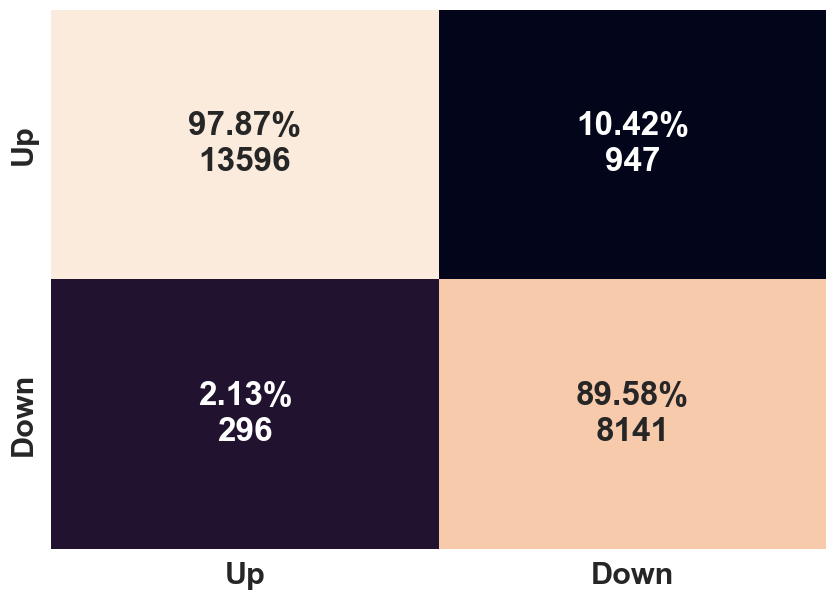

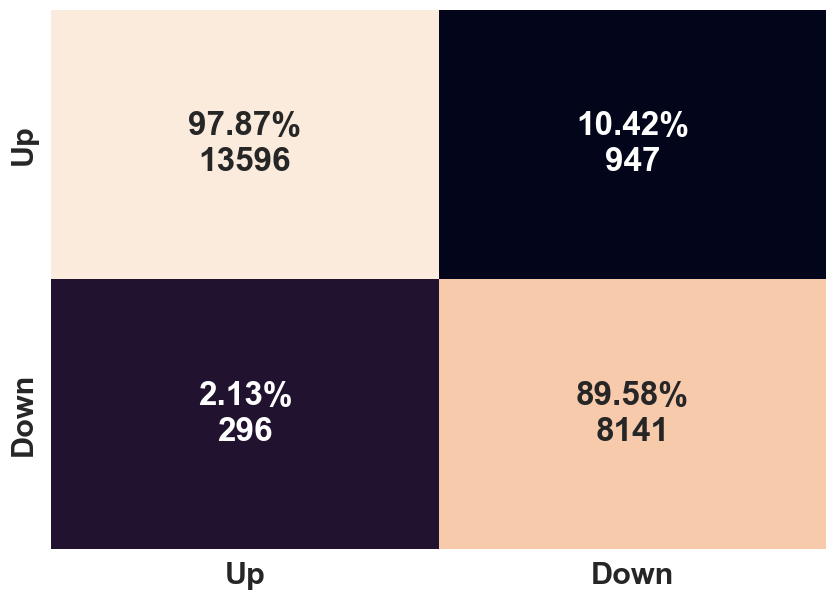

In [8]:
plot_confusionmatrix(
    cf=cf_matrix,
    categories=["Up", "Down"],
    figname="Conf_Matrix_before_transferlearning.png",
    ifshow=True,
)


## 2. Select the same 10% Texas transfer-learning subset


In [9]:
# The original notebook used np.random.permutation without fixing a seed.
# Set SEED to an integer if you want an exactly repeatable split; leave it as None
# to retain the original behavior.
SEED = None

if SEED is None:
    ind = np.random.permutation(len(datall))
else:
    rng = np.random.default_rng(SEED)
    ind = rng.permutation(len(datall))

a = int(10 * len(ind) / 100)
ind = ind[:a]
x = datall[ind].astype(np.float32, copy=False)
y = labtest[ind].astype(np.float32, copy=False)

# Keras validation_split=0.1 takes the final 10% of x/y as validation before
# epoch-wise shuffling. Reproduce that split explicitly here.
n_val = max(1, int(len(x) * 0.1))
x_train, y_train = x[:-n_val], y[:-n_val]
x_val, y_val = x[-n_val:], y[-n_val:]

print("selected 10%:", len(x))
print("training     :", len(x_train))
print("validation   :", len(x_val))


selected 10%: 2298
training     : 2069
validation   : 229


## 3. Fine-tune in PyTorch and checkpoint the best validation accuracy


In [ ]:
import datetime

today = datetime.date.today()
weightname = Path(f"best_weigths_Binary_Texas_Transfer10_{today}.pt")

BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-3

train_ds = TensorDataset(
    torch.from_numpy(x_train),
    torch.from_numpy(y_train.reshape(-1, 1)),
)
val_ds = TensorDataset(
    torch.from_numpy(x_val),
    torch.from_numpy(y_val.reshape(-1, 1)),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Reload the SCSN weights so fine-tuning always starts from the same pretrained model.
model = load_model("scsn", models_dir=MODEL_DIR, device=DEVICE)
model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=50,
    min_lr=0.5e-6,
)

best_val_acc = -np.inf
history = {
    "loss": [], "acc": [], "val_loss": [], "val_acc": [], "lr": []
}

for epoch in range(1, EPOCHS + 1):
    # ----- training -----
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_n = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model.logits(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        pred = (torch.sigmoid(logits) >= 0.5).to(yb.dtype)
        train_correct += (pred == yb).sum().item()
        train_n += xb.size(0)

    train_loss = train_loss_sum / train_n
    train_acc = train_correct / train_n

    # ----- validation -----
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_n = 0

    with torch.inference_mode():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            logits = model.logits(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)
            pred = (torch.sigmoid(logits) >= 0.5).to(yb.dtype)
            val_correct += (pred == yb).sum().item()
            val_n += xb.size(0)

    val_loss = val_loss_sum / val_n
    val_acc = val_correct / val_n
    current_lr = optimizer.param_groups[0]["lr"]

    history["loss"].append(train_loss)
    history["acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # Equivalent to Keras ModelCheckpoint(monitor='val_acc', mode='max',
    # save_weights_only=True, save_best_only=True).
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), weightname)
        marker = "  <-- saved best"
    else:
        marker = ""

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} - "
        f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - "
        f"lr: {current_lr:.3e}{marker}"
    )

print("\nBest validation accuracy:", best_val_acc)
print("Saved PyTorch weights    :", weightname)


## 4. Load the best fine-tuned checkpoint and predict all Texas traces


In [ ]:
# PyTorch 2.x state-dict checkpoint.
try:
    state = torch.load(weightname, map_location=DEVICE, weights_only=True)
except TypeError:  # compatibility with older PyTorch
    state = torch.load(weightname, map_location=DEVICE)

model.load_state_dict(state)
model.to(DEVICE).eval()

out = predict_proba(model, datall, batch_size=1024, device=DEVICE)
thre = 0.5
outtest = apply_threshold(out, thre)


In [ ]:
report_metrics(labtest, outtest)


In [ ]:
cf_matrix = confusion_matrix(labtest, outtest)
print(cf_matrix)


In [ ]:
plot_confusionmatrix(
    cf=cf_matrix,
    categories=["Up", "Down"],
    figname="Conf_Matrix_after_transferlearning.png",
    ifshow=True,
)
